In [355]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Tema geral
sns.set_theme(
    # style="whitegrid",
    palette="viridis",
    context="talk"
)

# Configurações globais dos gráficos
plt.rcParams["figure.figsize"] = (10,6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 13
plt.rcParams["xtick.labelsize"] = 11
plt.rcParams["ytick.labelsize"] = 11
plt.rcParams["legend.fontsize"] = 11
plt.rcParams["figure.autolayout"] = True

url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science/main/TelecomX_Data.json"
dados = pd.read_json(url)

dados


,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
...,...,...,...,...,...,...
7262,9987-LUTYD,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
7263,9992-RRAMN,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
7264,9992-UJOEL,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
7265,9993-LHIEB,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Two year', 'PaperlessBilling': '..."


In [356]:
pessoalclientes = pd.json_normalize(dados['customer'])
telefonesclientes = pd.json_normalize(dados['phone'])
contaclientes = pd.json_normalize(dados['account'])
customerID = dados['customerID']
churn = dados['Churn']

In [357]:
df = pd.concat([churn,customerID,pessoalclientes, telefonesclientes, contaclientes],axis=1)
df

,Churn,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,No,0002-ORFBO,Female,0,Yes,Yes,9,Yes,No,One year,Yes,Mailed check,65.60,593.3
1,No,0003-MKNFE,Male,0,No,No,9,Yes,Yes,Month-to-month,No,Mailed check,59.90,542.4
2,Yes,0004-TLHLJ,Male,0,No,No,4,Yes,No,Month-to-month,Yes,Electronic check,73.90,280.85
3,Yes,0011-IGKFF,Male,1,Yes,No,13,Yes,No,Month-to-month,Yes,Electronic check,98.00,1237.85
4,Yes,0013-EXCHZ,Female,1,Yes,No,3,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,No,9987-LUTYD,Female,0,No,No,13,Yes,No,One year,No,Mailed check,55.15,742.9
7263,Yes,9992-RRAMN,Male,0,Yes,No,22,Yes,Yes,Month-to-month,Yes,Electronic check,85.10,1873.7
7264,No,9992-UJOEL,Male,0,No,No,2,Yes,No,Month-to-month,Yes,Mailed check,50.30,92.75
7265,No,9993-LHIEB,Male,0,Yes,Yes,67,Yes,No,Two year,No,Mailed check,67.85,4627.65


In [358]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Churn             7267 non-null   object 
 1   customerID        7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   Contract          7267 non-null   object 
 10  PaperlessBilling  7267 non-null   object 
 11  PaymentMethod     7267 non-null   object 
 12  Charges.Monthly   7267 non-null   float64
 13  Charges.Total     7267 non-null   object 
dtypes: float64(1), int64(2), object(11)
memory usage: 795.0+ KB


In [359]:
df[df['Churn'].isna()]
df['Churn'].value_counts()


,count
Churn,
No,5174
Yes,1869
,224


In [360]:
df[df['Churn'].astype(str).str.strip() == ""]

,Churn,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
30,,0047-ZHDTW,Female,0,No,No,11,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),79.00,929.3
75,,0120-YZLQA,Male,0,No,No,71,Yes,No,Two year,Yes,Credit card (automatic),19.90,1355.1
96,,0154-QYHJU,Male,0,No,No,29,Yes,No,One year,Yes,Electronic check,58.75,1696.2
98,,0162-RZGMZ,Female,1,No,No,5,Yes,No,Month-to-month,No,Credit card (automatic),59.90,287.85
175,,0274-VVQOQ,Male,1,Yes,No,65,Yes,Yes,One year,Yes,Bank transfer (automatic),103.15,6792.45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7158,,9840-GSRFX,Female,0,No,No,14,Yes,Yes,One year,Yes,Mailed check,54.25,773.2
7180,,9872-RZQQB,Female,0,Yes,No,49,No,No phone service,Month-to-month,No,Bank transfer (automatic),40.65,2070.75
7211,,9920-GNDMB,Male,0,No,No,9,Yes,Yes,Month-to-month,Yes,Electronic check,76.25,684.85
7239,,9955-RVWSC,Female,0,Yes,Yes,67,Yes,No,Two year,Yes,Bank transfer (automatic),19.25,1372.9


In [361]:
# vou considerar as células vazias de Churn como 'Unknown' e não utilizarei essas linhas para o modelo, pois não tenho como saber se o cliente realmente cancelou ou não.
df[df['Churn'].astype(str).str.strip() == ""] = 'Unknown'

/tmp/ipykernel_1955/834727651.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Unknown' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df[df['Churn'].astype(str).str.strip() == ""] = 'Unknown'
/tmp/ipykernel_1955/834727651.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Unknown' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df[df['Churn'].astype(str).str.strip() == ""] = 'Unknown'
/tmp/ipykernel_1955/834727651.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Unknown' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df[df['Churn'].astype(str).str.strip() == ""] = 'Unknown'


In [362]:
df['Charges.Total'].value_counts()

,count
Charges.Total,
Unknown,224
20.2,11
,11
19.75,9
19.65,8
...,...
625.65,1
462.8,1
251.25,1


In [363]:
import numpy as np

# Converter para numérico
df['Charges.Monthly'] = pd.to_numeric(df['Charges.Monthly'], errors='coerce')

# Calcular charges diários
df['Charges.daily'] = df['Charges.Monthly'] / 30

df['Charges.daily']

,Charges.daily
0,2.186667
1,1.996667
2,2.463333
3,3.266667
4,2.796667
...,...
7262,1.838333
7263,2.836667
7264,1.676667
7265,2.261667


In [364]:
df.columns

Index(['Churn', 'customerID', 'gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Charges.Monthly', 'Charges.Total',
       'Charges.daily'],
      dtype='object')

In [365]:
#traduzindo minha tabela para português para facilitar a análise e o entendimento dos dados.
df.loc[df['gender'].astype(str).str.strip() == "Female", 'gender'] = 'Feminino'
df.loc[df['gender'].astype(str).str.strip() == "Male", 'gender'] = 'Masculino'

df.loc[df['Partner'].astype(str).str.strip() == "Yes", 'Partner'] = 'Sim'
df.loc[df['Partner'].astype(str).str.strip() == "No", 'Partner'] = 'Não'

df.loc[df['Dependents'].astype(str).str.strip() == "Yes", 'Dependents'] = 'Sim'
df.loc[df['Dependents'].astype(str).str.strip() == "No", 'Dependents'] = 'Não'

df.loc[df['PhoneService'].astype(str).str.strip() == "Yes", 'PhoneService'] = 'Sim'
df.loc[df['PhoneService'].astype(str).str.strip() == "No", 'PhoneService'] = 'Não'

df.loc[df['MultipleLines'].astype(str).str.strip() == "Yes", 'MultipleLines'] = 'Sim'
df.loc[df['MultipleLines'].astype(str).str.strip() == "No", 'MultipleLines'] = 'Não'
df.loc[df['MultipleLines'].astype(str).str.strip() == "No phone service", 'MultipleLines'] = 'Não possui serviço de telefone'

df.loc[df['Contract'].astype(str).str.strip() == "Month-to-month", 'Contract'] = 'Mês a mês'
df.loc[df['Contract'].astype(str).str.strip() == "One year", 'Contract'] = 'Ano a ano'
df.loc[df['Contract'].astype(str).str.strip() == "Two year", 'Contract'] = 'Dois anos'
df.loc[df['Contract'].astype(str).str.strip() == "Unknown", 'Contract'] = 'Desconecido'

df.loc[df['PaymentMethod'].astype(str).str.strip() == "Electronic check", 'PaymentMethod'] = 'Cheque eletrônico'
df.loc[df['PaymentMethod'].astype(str).str.strip() == "Mailed check", 'PaymentMethod'] = 'Cheque postal'
df.loc[df['PaymentMethod'].astype(str).str.strip() == "Bank transfer (automatic)", 'PaymentMethod'] = 'Transferência bancária automática'
df.loc[df['PaymentMethod'].astype(str).str.strip() == "Credit card (automatic)", 'PaymentMethod'] = 'Cartão de crédito automático'

df.loc[df['PaperlessBilling'].astype(str).str.strip() == "Yes", 'PaperlessBilling'] = 'Sim'
df.loc[df['PaperlessBilling'].astype(str).str.strip() == "No", 'PaperlessBilling'] = 'Não'

df.loc[df['Churn'].astype(str).str.strip() == "Yes", 'Churn'] = "Sim"
df.loc[df['Churn'].astype(str).str.strip() == "No", 'Churn'] = "Não"
df.loc[df['Churn'].astype(str).str.strip() == "Unknown", 'Churn'] = "Desconhecido"

In [366]:
df = df.rename(columns={
    'Churn': 'Cancelou',
    'customerID': 'ID_Cliente',
    'gender': 'Genero',
    'SeniorCitizen': 'Idoso',
    'Partner': 'Possui_Parceiro',
    'Dependents': 'Dependentes',
    'tenure': 'Tempo_de_Contrato',
    'PhoneService': 'Servico_Telefone',
    'MultipleLines': 'Multiplas_Linhas',
    'Contract': 'Tipo_Contrato',
    'PaperlessBilling': 'Fatura_Digital',
    'PaymentMethod': 'Metodo_Pagamento',
    'Charges.Monthly': 'Valor_Mensal',
    'Charges.Total': 'Valor_Total',
    'Charges.daily': 'Valor_Diario'
})

In [297]:
df

,Cancelou,ID_Cliente,Genero,Idoso,Possui_Parceiro,Dependentes,Tempo_de_Contrato,Servico_Telefone,Multiplas_Linhas,Tipo_Contrato,Fatura_Digital,Metodo_Pagamento,Valor_Mensal,Valor_Total,Valor_Diario
0,Não,0002-ORFBO,Feminino,0,Sim,Sim,9,Sim,Não,Ano a ano,Sim,Cheque postal,65.60,593.3,2.186667
1,Não,0003-MKNFE,Masculino,0,Não,Não,9,Sim,Sim,Mês a mês,Não,Cheque postal,59.90,542.4,1.996667
2,Sim,0004-TLHLJ,Masculino,0,Não,Não,4,Sim,Não,Mês a mês,Sim,Cheque eletrônico,73.90,280.85,2.463333
3,Sim,0011-IGKFF,Masculino,1,Sim,Não,13,Sim,Não,Mês a mês,Sim,Cheque eletrônico,98.00,1237.85,3.266667
4,Sim,0013-EXCHZ,Feminino,1,Sim,Não,3,Sim,Não,Mês a mês,Sim,Cheque postal,83.90,267.4,2.796667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,Não,9987-LUTYD,Feminino,0,Não,Não,13,Sim,Não,Ano a ano,Não,Cheque postal,55.15,742.9,1.838333
7263,Sim,9992-RRAMN,Masculino,0,Sim,Não,22,Sim,Sim,Mês a mês,Sim,Cheque eletrônico,85.10,1873.7,2.836667
7264,Não,9992-UJOEL,Masculino,0,Não,Não,2,Sim,Não,Mês a mês,Sim,Cheque postal,50.30,92.75,1.676667
7265,Não,9993-LHIEB,Masculino,0,Sim,Sim,67,Sim,Não,Dois anos,Não,Cheque postal,67.85,4627.65,2.261667


In [298]:
df.describe()

,Valor_Mensal,Valor_Diario
count,7043.000000,7043.000000
mean,64.761692,2.158723
std,30.090047,1.003002
min,18.250000,0.608333
25%,35.500000,1.183333
50%,70.350000,2.345000
75%,89.850000,2.995000
max,118.750000,3.958333


###Distribuição da Evasão

In [299]:
clientes_cancelou_ou_nao = df['Cancelou'].value_counts()
clientes_cancelou_ou_nao

,count
Cancelou,
Não,5174
Sim,1869
Desconhecido,224


In [300]:
import matplotlib.pyplot as py



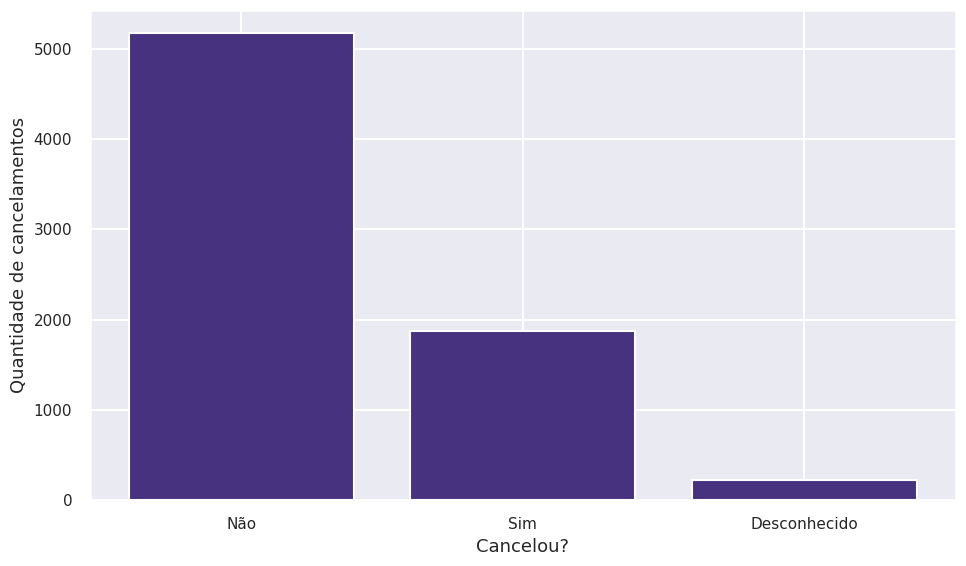

In [301]:
plt.bar(clientes_cancelou_ou_nao.index, clientes_cancelou_ou_nao.values)
plt.xlabel('Cancelou?')
plt.ylabel('Quantidade de cancelamentos')
plt.show()

In [302]:

cancelados_tipo_contrato = df[df['Cancelou'] == 'Sim']['Cancelou'].groupby(df[df['Cancelou'] == 'Sim']['Tipo_Contrato']).value_counts()
cancelados_tipo_contrato = cancelados_tipo_contrato.reset_index(name='Quantidade')
cancelados_tipo_contrato = cancelados_tipo_contrato.drop(columns=['Cancelou'])
cancelados_tipo_contrato

,Tipo_Contrato,Quantidade
0,Ano a ano,166
1,Dois anos,48
2,Mês a mês,1655


### Explorando Variáveis categóricas ###

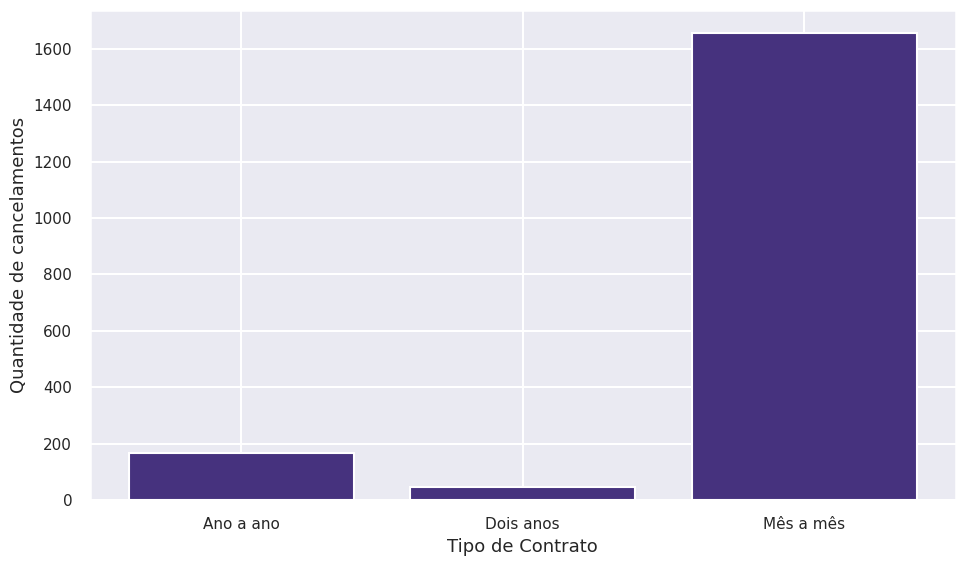

In [303]:
plt.bar(cancelados_tipo_contrato['Tipo_Contrato'], cancelados_tipo_contrato['Quantidade'])
plt.xlabel('Tipo de Contrato')
plt.ylabel('Quantidade de cancelamentos')
plt.show()

In [304]:
df.columns

Index(['Cancelou', 'ID_Cliente', 'Genero', 'Idoso', 'Possui_Parceiro',
       'Dependentes', 'Tempo_de_Contrato', 'Servico_Telefone',
       'Multiplas_Linhas', 'Tipo_Contrato', 'Fatura_Digital',
       'Metodo_Pagamento', 'Valor_Mensal', 'Valor_Total', 'Valor_Diario'],
      dtype='object')

In [305]:
cancelados_genero = df[df['Cancelou'] == 'Sim']['Cancelou'].groupby(df[df['Cancelou'] == 'Sim']['Genero']).value_counts()
cancelados_genero = cancelados_genero.reset_index(name='Quantidade')
cancelados_genero = cancelados_genero.drop(columns=['Cancelou'])

In [306]:
cancelados_genero

,Genero,Quantidade
0,Feminino,939
1,Masculino,930


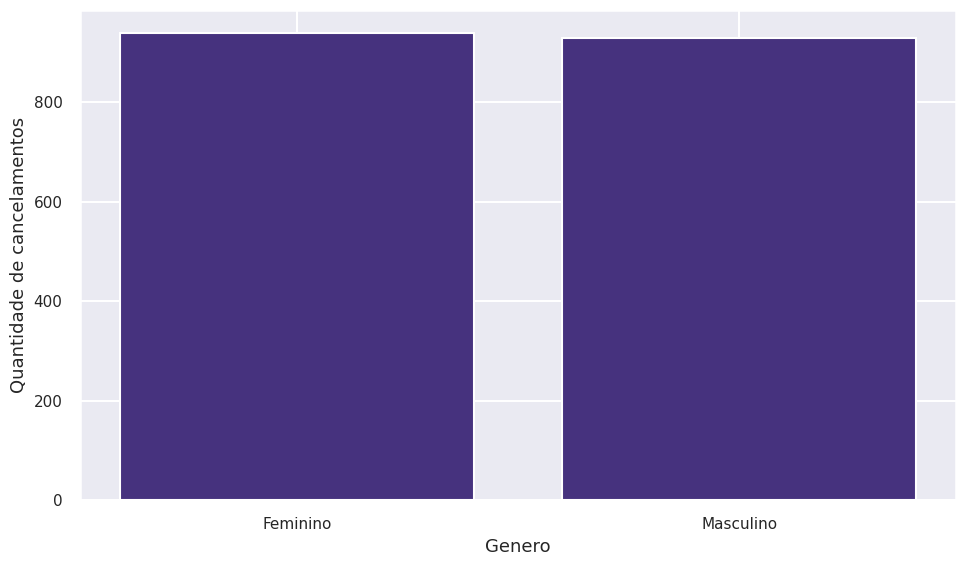

In [307]:
plt.bar(cancelados_genero['Genero'], cancelados_genero['Quantidade'])
plt.xlabel('Genero')
plt.ylabel('Quantidade de cancelamentos')
plt.show()

In [308]:
cancelados_metodo_pagamento = df[df['Cancelou'] == 'Sim']['Cancelou'].groupby(df[df['Cancelou'] == 'Sim']['Metodo_Pagamento']).value_counts()
cancelados_metodo_pagamento = cancelados_metodo_pagamento.reset_index(name='Quantidade')
cancelados_metodo_pagamento = cancelados_metodo_pagamento.drop(columns=['Cancelou'])

In [309]:
cancelados_metodo_pagamento

,Metodo_Pagamento,Quantidade
0,Cartão de crédito automático,232
1,Cheque eletrônico,1071
2,Cheque postal,308
3,Transferência bancária automática,258


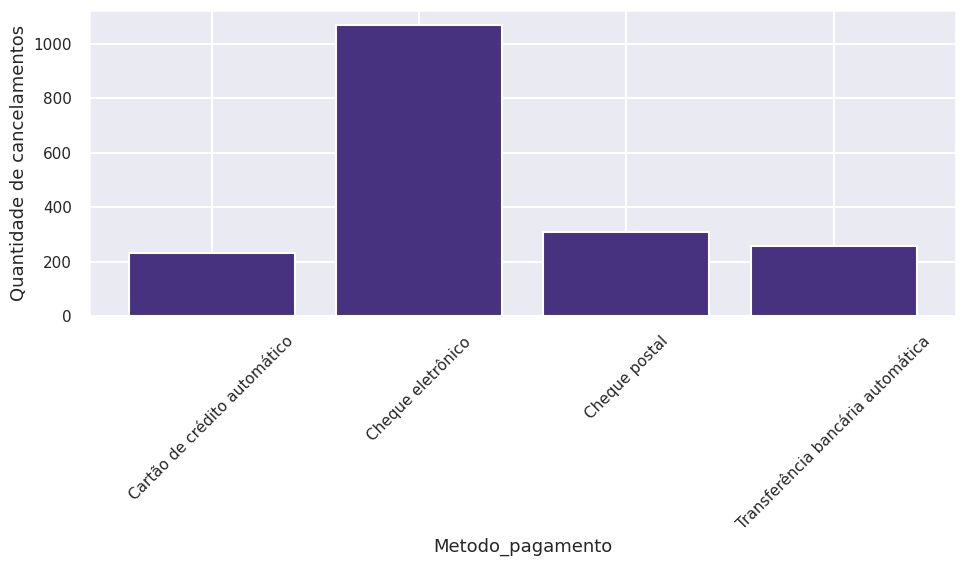

In [310]:
plt.bar(cancelados_metodo_pagamento['Metodo_Pagamento'], cancelados_metodo_pagamento['Quantidade'])
plt.xlabel('Metodo_pagamento')
plt.xticks(rotation=45)
plt.ylabel('Quantidade de cancelamentos')
plt.show()

In [311]:
cancelados_fatura_digital = df[df['Cancelou'] == 'Sim']['Cancelou'].groupby(df[df['Cancelou'] == 'Sim']['Fatura_Digital']).value_counts()
cancelados_fatura_digital = cancelados_fatura_digital.reset_index(name='Quantidade')
cancelados_fatura_digital = cancelados_fatura_digital.drop(columns=['Cancelou'])

In [312]:
cancelados_fatura_digital

,Fatura_Digital,Quantidade
0,Não,469
1,Sim,1400


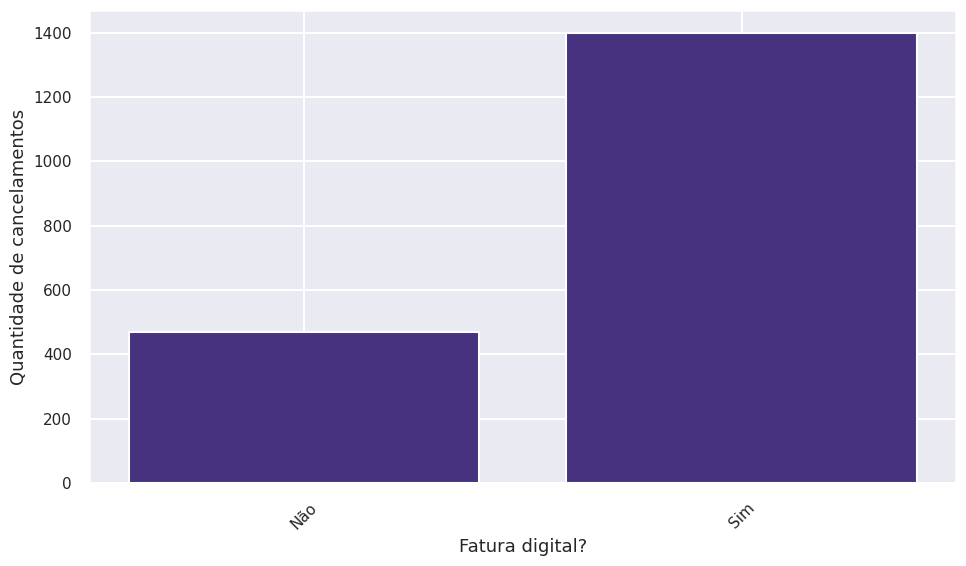

In [313]:
plt.bar(cancelados_fatura_digital['Fatura_Digital'], cancelados_fatura_digital['Quantidade'])
plt.xlabel('Fatura digital?')
plt.xticks(rotation=45)
plt.ylabel('Quantidade de cancelamentos')
plt.show()

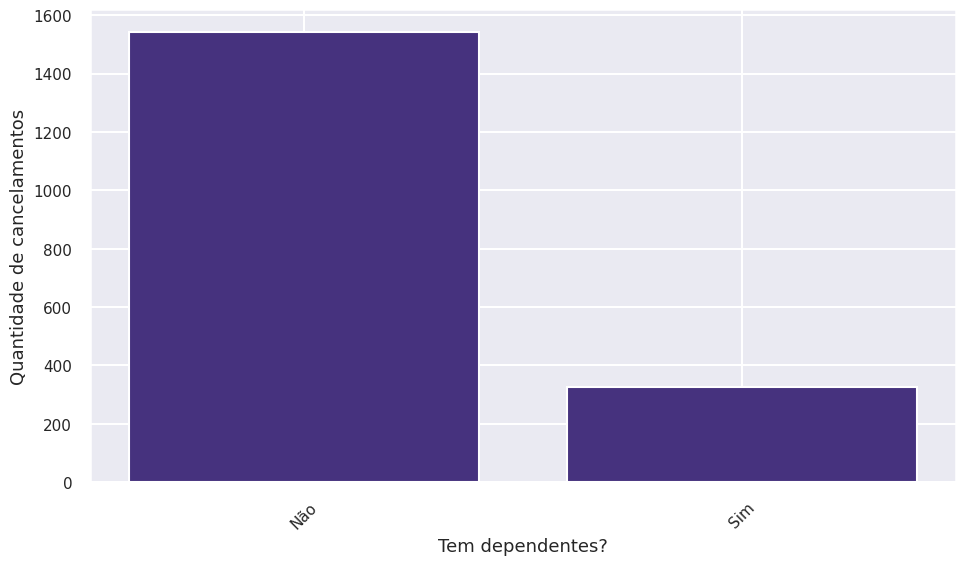

In [314]:
cancelados_dependentes= df[df['Cancelou'] == 'Sim']['Cancelou'].groupby(df[df['Cancelou'] == 'Sim']['Dependentes']).value_counts()
cancelados_dependentes= cancelados_dependentes.reset_index(name='Quantidade')
cancelados_dependentes= cancelados_dependentes.drop(columns=['Cancelou'])

plt.bar(cancelados_dependentes['Dependentes'], cancelados_dependentes['Quantidade'])
plt.xlabel('Tem dependentes?')
plt.xticks(rotation=45)
plt.ylabel('Quantidade de cancelamentos')
plt.show()

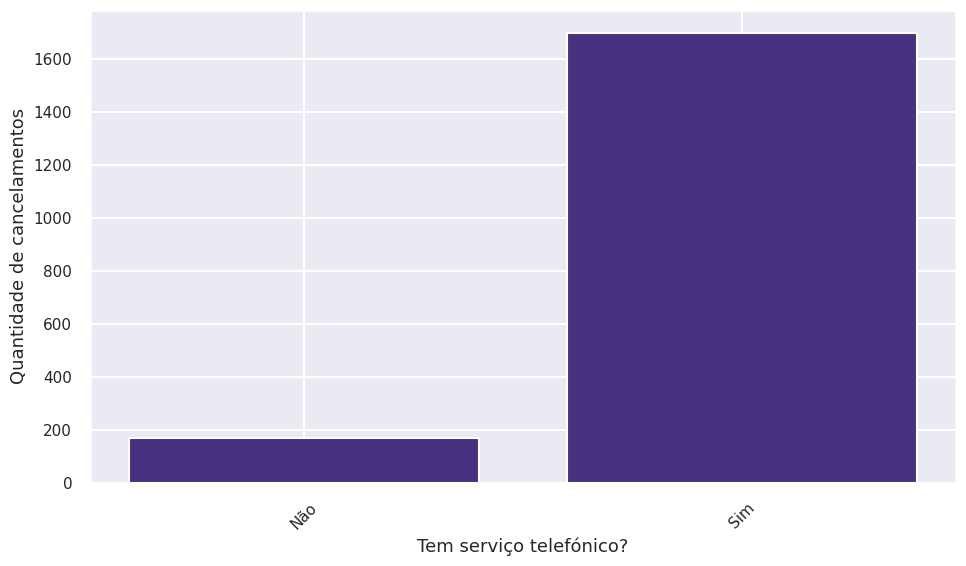

In [315]:
cancelados_servico= df[df['Cancelou'] == 'Sim']['Cancelou'].groupby(df[df['Cancelou'] == 'Sim']['Servico_Telefone']).value_counts()
cancelados_servico= cancelados_servico.reset_index(name='Quantidade')
cancelados_servico= cancelados_servico.drop(columns=['Cancelou'])

plt.bar(cancelados_servico['Servico_Telefone'], cancelados_servico['Quantidade'])
plt.xlabel('Tem serviço telefónico?')
plt.xticks(rotation=45)
plt.ylabel('Quantidade de cancelamentos')
plt.show()

###Variáveis numéricas

In [316]:
df.columns

Index(['Cancelou', 'ID_Cliente', 'Genero', 'Idoso', 'Possui_Parceiro',
       'Dependentes', 'Tempo_de_Contrato', 'Servico_Telefone',
       'Multiplas_Linhas', 'Tipo_Contrato', 'Fatura_Digital',
       'Metodo_Pagamento', 'Valor_Mensal', 'Valor_Total', 'Valor_Diario'],
      dtype='object')

In [317]:
cancelados_total_gasto = df[df['Cancelou'] == 'Sim']['Cancelou'].groupby(df[df['Cancelou'] == 'Sim']['Valor_Total']).value_counts()
cancelados_total_gasto = cancelados_total_gasto.reset_index(name='Quantidade')
cancelados_total_gasto = cancelados_total_gasto.drop(columns=['Cancelou'])

In [318]:
cancelados_total_gasto

,Valor_Total,Quantidade
0,100.25,1
1,100.4,1
2,100.8,1
3,1008.55,1
4,1008.7,1
...,...,...
1727,990.9,1
1728,994.55,1
1729,994.8,1
1730,997.65,1


In [319]:
cancelados_total_gasto.max()

,0
Valor_Total,999.45
Quantidade,6


In [320]:
faixas = [0, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]

# Converter 'Valor_Total' para numérico, tratando erros
cancelados_total_gasto['Valor_Total'] = pd.to_numeric(cancelados_total_gasto['Valor_Total'], errors='coerce')

#ranges
cancelados_total_gasto['Faixas'] = pd.cut(cancelados_total_gasto['Valor_Total'], bins=faixas)
cancelados_total_gasto = cancelados_total_gasto.drop(columns=['Valor_Total'])
cancelados_total_gasto = cancelados_total_gasto.groupby('Faixas').sum()


cancelados_total_gasto

/tmp/ipykernel_1955/3144410407.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cancelados_total_gasto = cancelados_total_gasto.groupby('Faixas').sum()


,Quantidade
Faixas,
"(0, 100]",431
"(100, 200]",143
"(200, 300]",106
"(300, 400]",83
"(400, 500]",66
"(500, 600]",54
"(600, 700]",50
"(700, 800]",44
"(800, 900]",55


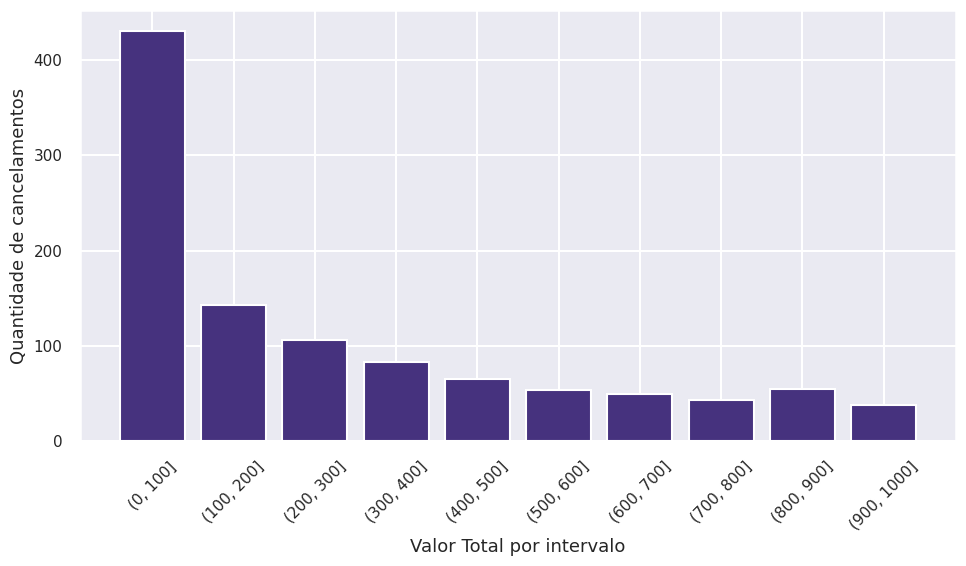

In [321]:
plt.bar(cancelados_total_gasto.index.astype(str), cancelados_total_gasto['Quantidade'])
plt.xlabel('Valor Total por intervalo')
plt.xticks(rotation=45)
plt.ylabel('Quantidade de cancelamentos')
plt.show()

In [322]:
cancelados_tempo_contrado = df[df['Cancelou'] == 'Sim']['Cancelou'].groupby(df[df['Cancelou'] == 'Sim']['Tempo_de_Contrato']).value_counts()
cancelados_tempo_contrado = cancelados_tempo_contrado.reset_index(name='Quantidade')
cancelados_tempo_contrado = cancelados_tempo_contrado.drop(columns=['Cancelou'])

In [323]:
cancelados_tempo_contrado

,Tempo_de_Contrato,Quantidade
0,1,380
1,2,123
2,3,94
3,4,83
4,5,64
...,...,...
67,68,9
68,69,8
69,70,11
70,71,6


In [324]:
faixas = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]

# Converter 'Tempo_de_Contrato' para numérico, tratando erros
cancelados_tempo_contrado['Tempo_de_Contrato'] = pd.to_numeric(cancelados_tempo_contrado['Tempo_de_Contrato'], errors='coerce')

#ranges
cancelados_tempo_contrado['Faixas'] = pd.cut(cancelados_tempo_contrado['Tempo_de_Contrato'], bins=faixas)
cancelados_tempo_contrado = cancelados_tempo_contrado.drop(columns=['Tempo_de_Contrato'])
cancelados_tempo_contrado = cancelados_tempo_contrado.groupby('Faixas').sum()


cancelados_tempo_contrado

/tmp/ipykernel_1955/472099390.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cancelados_tempo_contrado = cancelados_tempo_contrado.groupby('Faixas').sum()


,Quantidade
Faixas,
"(0, 10]",968
"(10, 20]",283
"(20, 30]",174
"(30, 40]",141
"(40, 50]",115
"(50, 60]",95
"(60, 70]",81
"(70, 80]",12
"(80, 90]",0


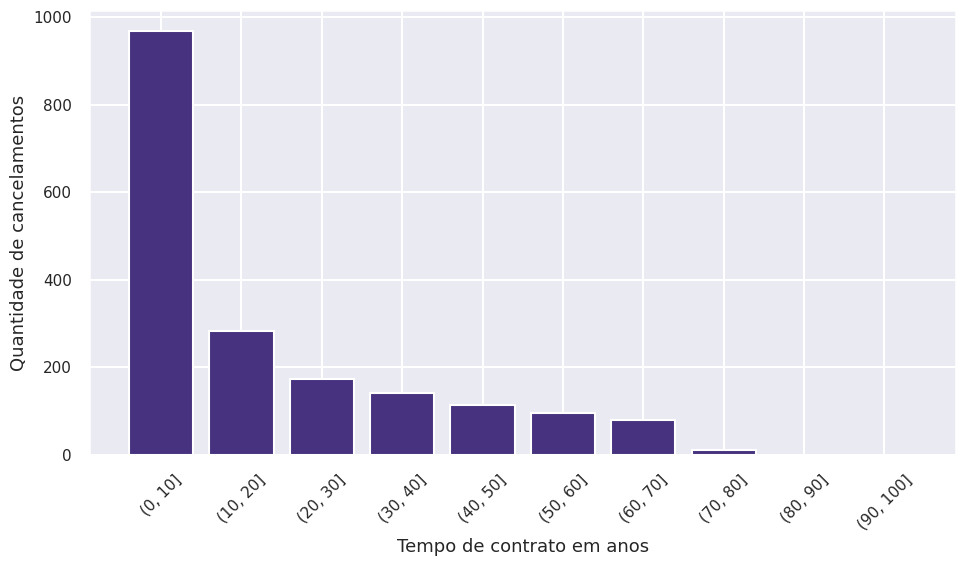

In [325]:
plt.bar(cancelados_tempo_contrado.index.astype(str), cancelados_tempo_contrado['Quantidade'])
plt.xlabel('Tempo de contrato em anos')
plt.xticks(rotation=45)
plt.ylabel('Quantidade de cancelamentos')
plt.show()

# 📊 Relatório de Análise de Evasão de Clientes (Churn)

## 1. Introdução

A evasão de clientes, conhecida como **Churn**, ocorre quando um cliente deixa de utilizar os serviços de uma empresa. Esse é um dos principais desafios enfrentados por empresas de telecomunicações, pois a perda de clientes impacta diretamente a receita e os custos de aquisição de novos consumidores.

O objetivo desta análise foi investigar os dados de clientes da TelecomX para identificar padrões associados à evasão. A partir dessa análise, buscamos compreender quais fatores influenciam o cancelamento dos serviços e gerar insights que possam auxiliar na criação de estratégias para retenção de clientes.

---

## 2. Limpeza e Tratamento de Dados

A etapa inicial do projeto consistiu na importação e preparação dos dados para análise.

Os dados foram carregados em um DataFrame utilizando a biblioteca **pandas**, permitindo manipulação eficiente das informações.

Durante o processo de limpeza e tratamento foram realizadas as seguintes etapas:

- Importação dos dados para o ambiente de análise.
- Normalização de colunas estruturadas em formato JSON.
- Separação e organização das informações em diferentes categorias de dados.
- Tratamento de valores ausentes ou inconsistentes.
- Conversão de variáveis categóricas para facilitar a análise.
- Padronização dos nomes das colunas para melhor leitura e manipulação.

Essas etapas foram fundamentais para garantir que os dados estivessem organizados, consistentes e adequados para as análises posteriores.

---

## 3. Análise Exploratória de Dados

A análise exploratória de dados teve como objetivo identificar padrões e relações entre as variáveis presentes no conjunto de dados.

Diversas visualizações gráficas foram utilizadas para facilitar a compreensão dos dados e destacar possíveis tendências relacionadas ao churn.

### Distribuição de Churn

Inicialmente foi analisada a proporção de clientes que cancelaram o serviço em comparação com aqueles que permaneceram ativos. Essa análise permite entender o nível geral de evasão dentro da base de clientes.

### Tipo de Contrato

Foi analisada a relação entre o tipo de contrato e a evasão de clientes. Observou-se que clientes com **contratos mensais** apresentam maior probabilidade de cancelamento quando comparados com clientes que possuem contratos de maior duração.

### Gastos Mensais e Totais

Também foram analisadas variáveis relacionadas aos valores pagos pelos clientes.

Os resultados indicaram que:

- Clientes com **valores mensais mais altos** tendem a apresentar maior taxa de evasão.
- A análise dos **gastos totais** também contribui para identificar perfis de clientes com maior risco de cancelamento.

---

## 4. Conclusões e Insights

A análise dos dados permitiu identificar alguns padrões importantes relacionados à evasão de clientes.

Entre os principais achados estão:

- Clientes com **contratos mensais** apresentam maior tendência a cancelar os serviços.
- Valores **mensais elevados** podem estar associados a uma maior probabilidade de churn.
- Determinadas combinações de serviços podem influenciar a permanência ou cancelamento do cliente.
- Clientes com **menor tempo de relacionamento com a empresa** podem apresentar maior risco de evasão.

Esses insights permitem compreender melhor o comportamento dos clientes e identificar grupos que apresentam maior probabilidade de cancelamento.

---

## 5. Recomendações

Com base nos resultados da análise, algumas estratégias podem ser adotadas para reduzir a evasão de clientes:

- Incentivar contratos de **maior duração**, oferecendo benefícios ou descontos para planos anuais.
- Monitorar clientes com **altos valores mensais**, oferecendo planos mais adequados ou promoções personalizadas.
- Criar **programas de fidelização** para clientes novos, reduzindo a probabilidade de cancelamento nos primeiros meses.
- Melhorar continuamente a **experiência do cliente**, avaliando feedbacks e possíveis dificuldades no uso dos serviços.
- Implementar **modelos preditivos de churn** para identificar clientes com maior risco de cancelamento e agir de forma preventiva.

A utilização dessas estratégias pode contribuir significativamente para aumentar a retenção de clientes e melhorar os resultados da empresa.

In [326]:
df.head()

,Cancelou,ID_Cliente,Genero,Idoso,Possui_Parceiro,Dependentes,Tempo_de_Contrato,Servico_Telefone,Multiplas_Linhas,Tipo_Contrato,Fatura_Digital,Metodo_Pagamento,Valor_Mensal,Valor_Total,Valor_Diario
0,Não,0002-ORFBO,Feminino,0,Sim,Sim,9,Sim,Não,Ano a ano,Sim,Cheque postal,65.6,593.3,2.186667
1,Não,0003-MKNFE,Masculino,0,Não,Não,9,Sim,Sim,Mês a mês,Não,Cheque postal,59.9,542.4,1.996667
2,Sim,0004-TLHLJ,Masculino,0,Não,Não,4,Sim,Não,Mês a mês,Sim,Cheque eletrônico,73.9,280.85,2.463333
3,Sim,0011-IGKFF,Masculino,1,Sim,Não,13,Sim,Não,Mês a mês,Sim,Cheque eletrônico,98.0,1237.85,3.266667
4,Sim,0013-EXCHZ,Feminino,1,Sim,Não,3,Sim,Não,Mês a mês,Sim,Cheque postal,83.9,267.4,2.796667


In [327]:
df.drop(columns=['ID_Cliente'], inplace=True)
df

,Cancelou,Genero,Idoso,Possui_Parceiro,Dependentes,Tempo_de_Contrato,Servico_Telefone,Multiplas_Linhas,Tipo_Contrato,Fatura_Digital,Metodo_Pagamento,Valor_Mensal,Valor_Total,Valor_Diario
0,Não,Feminino,0,Sim,Sim,9,Sim,Não,Ano a ano,Sim,Cheque postal,65.60,593.3,2.186667
1,Não,Masculino,0,Não,Não,9,Sim,Sim,Mês a mês,Não,Cheque postal,59.90,542.4,1.996667
2,Sim,Masculino,0,Não,Não,4,Sim,Não,Mês a mês,Sim,Cheque eletrônico,73.90,280.85,2.463333
3,Sim,Masculino,1,Sim,Não,13,Sim,Não,Mês a mês,Sim,Cheque eletrônico,98.00,1237.85,3.266667
4,Sim,Feminino,1,Sim,Não,3,Sim,Não,Mês a mês,Sim,Cheque postal,83.90,267.4,2.796667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,Não,Feminino,0,Não,Não,13,Sim,Não,Ano a ano,Não,Cheque postal,55.15,742.9,1.838333
7263,Sim,Masculino,0,Sim,Não,22,Sim,Sim,Mês a mês,Sim,Cheque eletrônico,85.10,1873.7,2.836667
7264,Não,Masculino,0,Não,Não,2,Sim,Não,Mês a mês,Sim,Cheque postal,50.30,92.75,1.676667
7265,Não,Masculino,0,Sim,Sim,67,Sim,Não,Dois anos,Não,Cheque postal,67.85,4627.65,2.261667


In [328]:
df.columns

Index(['Cancelou', 'Genero', 'Idoso', 'Possui_Parceiro', 'Dependentes',
       'Tempo_de_Contrato', 'Servico_Telefone', 'Multiplas_Linhas',
       'Tipo_Contrato', 'Fatura_Digital', 'Metodo_Pagamento', 'Valor_Mensal',
       'Valor_Total', 'Valor_Diario'],
      dtype='object')

In [329]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Cancelou           7267 non-null   object 
 1   Genero             7267 non-null   object 
 2   Idoso              7267 non-null   object 
 3   Possui_Parceiro    7267 non-null   object 
 4   Dependentes        7267 non-null   object 
 5   Tempo_de_Contrato  7267 non-null   object 
 6   Servico_Telefone   7267 non-null   object 
 7   Multiplas_Linhas   7267 non-null   object 
 8   Tipo_Contrato      7267 non-null   object 
 9   Fatura_Digital     7267 non-null   object 
 10  Metodo_Pagamento   7267 non-null   object 
 11  Valor_Mensal       7043 non-null   float64
 12  Valor_Total        7267 non-null   object 
 13  Valor_Diario       7043 non-null   float64
dtypes: float64(2), object(12)
memory usage: 795.0+ KB


In [330]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Idoso'] = df['Idoso'].astype(str)

colunas_categoricas = ['Cancelou', 'Genero', 'Possui_Parceiro', 'Dependentes',
       'Servico_Telefone', 'Multiplas_Linhas',
       'Tipo_Contrato', 'Fatura_Digital', 'Metodo_Pagamento', 'Idoso']


for col in colunas_categoricas:
    df[col] = le.fit_transform(df[col])



In [331]:
df

,Cancelou,Genero,Idoso,Possui_Parceiro,Dependentes,Tempo_de_Contrato,Servico_Telefone,Multiplas_Linhas,Tipo_Contrato,Fatura_Digital,Metodo_Pagamento,Valor_Mensal,Valor_Total,Valor_Diario
0,1,0,0,1,1,9,1,0,0,1,2,65.60,593.3,2.186667
1,1,1,0,0,0,9,1,2,3,0,2,59.90,542.4,1.996667
2,2,1,0,0,0,4,1,0,3,1,1,73.90,280.85,2.463333
3,2,1,1,1,0,13,1,0,3,1,1,98.00,1237.85,3.266667
4,2,0,1,1,0,3,1,0,3,1,2,83.90,267.4,2.796667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,1,0,0,0,0,13,1,0,0,0,2,55.15,742.9,1.838333
7263,2,1,0,1,0,22,1,2,3,1,1,85.10,1873.7,2.836667
7264,1,1,0,0,0,2,1,0,3,1,2,50.30,92.75,1.676667
7265,1,1,0,1,1,67,1,0,2,0,2,67.85,4627.65,2.261667


In [332]:

df['Tempo_de_Contrato'] = pd.to_numeric(df['Tempo_de_Contrato'], errors='coerce').fillna(0).astype(int)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Cancelou           7267 non-null   int64  
 1   Genero             7267 non-null   int64  
 2   Idoso              7267 non-null   int64  
 3   Possui_Parceiro    7267 non-null   int64  
 4   Dependentes        7267 non-null   int64  
 5   Tempo_de_Contrato  7267 non-null   int64  
 6   Servico_Telefone   7267 non-null   int64  
 7   Multiplas_Linhas   7267 non-null   int64  
 8   Tipo_Contrato      7267 non-null   int64  
 9   Fatura_Digital     7267 non-null   int64  
 10  Metodo_Pagamento   7267 non-null   int64  
 11  Valor_Mensal       7043 non-null   float64
 12  Valor_Total        7267 non-null   object 
 13  Valor_Diario       7043 non-null   float64
dtypes: float64(2), int64(11), object(1)
memory usage: 795.0+ KB


In [333]:
corr = df.corr(numeric_only=True)
print(corr)

                   Cancelou    Genero     Idoso  Possui_Parceiro  Dependentes  \
Cancelou           1.000000 -0.215758 -0.194641        -0.330003    -0.368312   
Genero            -0.215758  1.000000  0.304958         0.217236     0.261623   
Idoso             -0.194641  0.304958  1.000000         0.320747     0.226520   
Possui_Parceiro   -0.330003  0.217236  0.320747         1.000000     0.591484   
Dependentes       -0.368312  0.261623  0.226520         0.591484     1.000000   
Tempo_de_Contrato -0.205201 -0.100410 -0.136369         0.220403     0.007253   
Servico_Telefone  -0.236324  0.248856  0.364835         0.269745     0.296702   
Multiplas_Linhas  -0.128357  0.160020  0.337410         0.284972     0.174930   
Tipo_Contrato      0.335776 -0.083958 -0.042795        -0.232692    -0.212030   
Fatura_Digital    -0.048871  0.199582  0.401179         0.199605     0.161970   
Metodo_Pagamento  -0.238039  0.175007  0.212191         0.197033     0.244193   
Valor_Mensal       0.193356 

<Axes: >

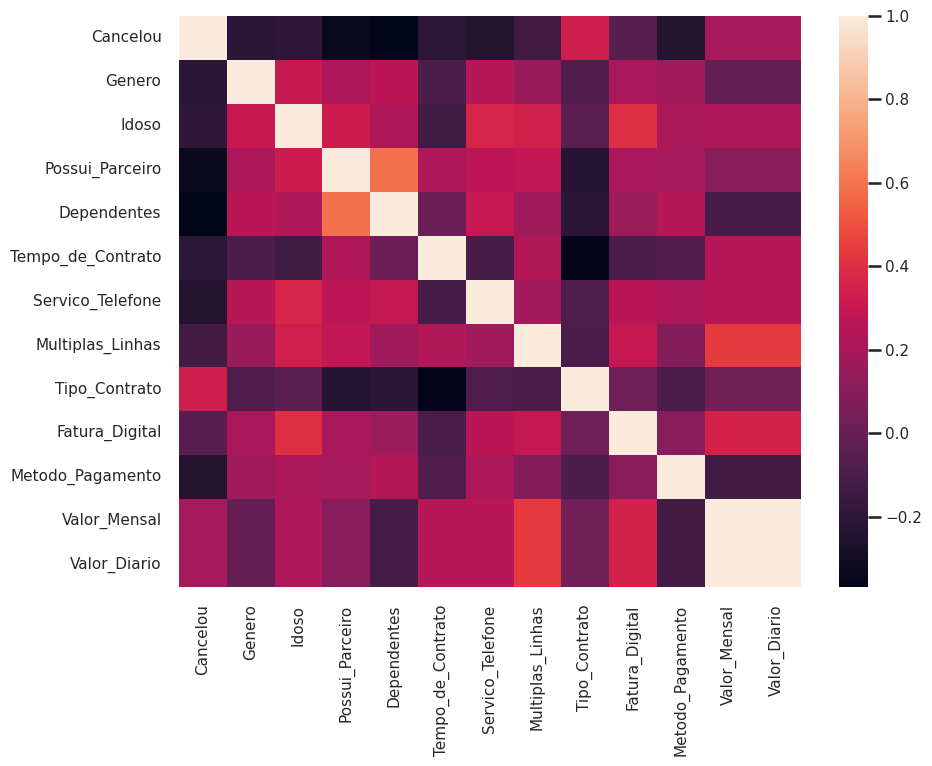

In [334]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr)

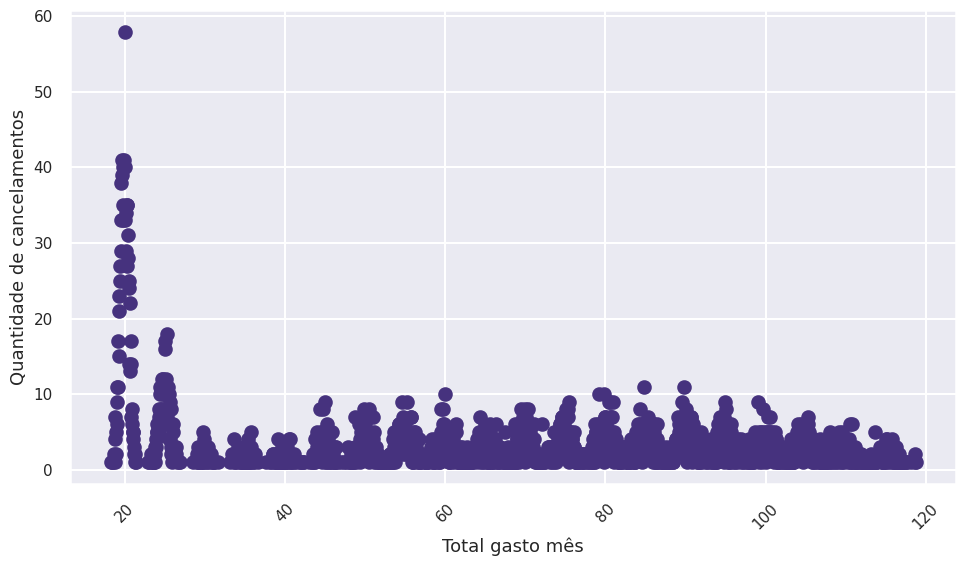

In [335]:
cancelados_dependentes= df[df['Cancelou'] == 1]['Cancelou'].groupby(df[df['Cancelou'] == 1]['Valor_Mensal']).value_counts()
cancelados_dependentes= cancelados_dependentes.reset_index(name='Quantidade')
cancelados_dependentes= cancelados_dependentes.drop(columns=['Cancelou'])

plt.scatter(cancelados_dependentes['Valor_Mensal'], cancelados_dependentes['Quantidade'])
plt.xlabel('Total gasto mês')
plt.xticks(rotation=45)
plt.ylabel('Quantidade de cancelamentos')
plt.show()

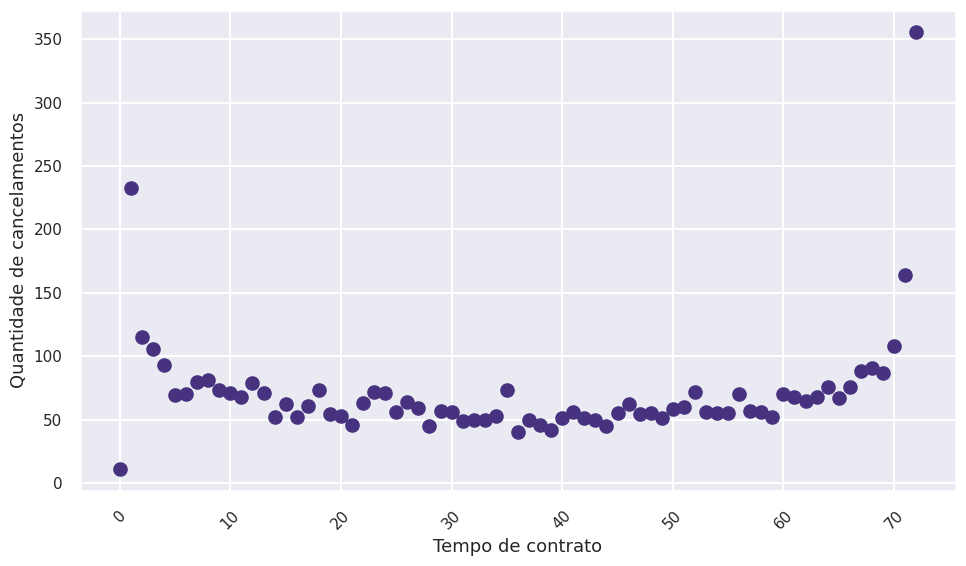

In [336]:
cancelados_dependentes= df[df['Cancelou'] == 1]['Cancelou'].groupby(df[df['Cancelou'] == 1]['Tempo_de_Contrato']).value_counts()
cancelados_dependentes= cancelados_dependentes.reset_index(name='Quantidade')
cancelados_dependentes= cancelados_dependentes.drop(columns=['Cancelou'])

plt.scatter(cancelados_dependentes['Tempo_de_Contrato'], cancelados_dependentes['Quantidade'])
plt.xlabel('Tempo de contrato')
plt.xticks(rotation=45)
plt.ylabel('Quantidade de cancelamentos')
plt.show()

In [337]:
df.columns

Index(['Cancelou', 'Genero', 'Idoso', 'Possui_Parceiro', 'Dependentes',
       'Tempo_de_Contrato', 'Servico_Telefone', 'Multiplas_Linhas',
       'Tipo_Contrato', 'Fatura_Digital', 'Metodo_Pagamento', 'Valor_Mensal',
       'Valor_Total', 'Valor_Diario'],
      dtype='object')

In [338]:
df.drop(columns=['Valor_Diario','Servico_Telefone', 'Metodo_Pagamento', 'Genero', 'Idoso'], inplace=True) #retirado porque já está representado pelo valor mensal

df

,Cancelou,Possui_Parceiro,Dependentes,Tempo_de_Contrato,Multiplas_Linhas,Tipo_Contrato,Fatura_Digital,Valor_Mensal,Valor_Total
0,1,1,1,9,0,0,1,65.60,593.3
1,1,0,0,9,2,3,0,59.90,542.4
2,2,0,0,4,0,3,1,73.90,280.85
3,2,1,0,13,0,3,1,98.00,1237.85
4,2,1,0,3,0,3,1,83.90,267.4
...,...,...,...,...,...,...,...,...,...
7262,1,0,0,13,0,0,0,55.15,742.9
7263,2,1,0,22,2,3,1,85.10,1873.7
7264,1,0,0,2,0,3,1,50.30,92.75
7265,1,1,1,67,0,2,0,67.85,4627.65


In [339]:
df["Cancelou"].value_counts()

#a quantidade de cancelamentos é muito maior que a quantidade de quem não cancelou, sendo assim é importante aplicar alguma ferramenta para balancear um pouco e evitar que a classe dominante se sobressaia muito em relação aos da classe com menor frequência.

,count
Cancelou,
1,5174
2,1869
0,224


In [340]:
df['Valor_Total'] = pd.to_numeric(df['Valor_Total'], errors='coerce')
df['Valor_Total'] = df['Valor_Total'].fillna(df['Valor_Total'].median())
df['Valor_Mensal'] = df['Valor_Mensal'].fillna(df['Valor_Mensal'].median())

In [341]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Cancelou           7267 non-null   int64  
 1   Possui_Parceiro    7267 non-null   int64  
 2   Dependentes        7267 non-null   int64  
 3   Tempo_de_Contrato  7267 non-null   int64  
 4   Multiplas_Linhas   7267 non-null   int64  
 5   Tipo_Contrato      7267 non-null   int64  
 6   Fatura_Digital     7267 non-null   int64  
 7   Valor_Mensal       7267 non-null   float64
 8   Valor_Total        7267 non-null   float64
dtypes: float64(2), int64(7)
memory usage: 511.1 KB


In [342]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

X = df.drop('Cancelou', axis=1)
y = df['Cancelou']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)



In [343]:
from sklearn.preprocessing import StandardScaler

# adicionei o scaler para normalizar uma vez que tenho colunas com valores muito mais altos que outras
# essa normalização não é necessária para modelos de Random Classifier, mas já que eu quero utilizar o de Regressão Logística também então quis usar ambos com a normalização

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [344]:
X_train

array([[-1.06330401, -0.89442927,  0.54838976, ..., -0.08578755,
         1.10633128,  0.65349295],
       [ 0.09674048, -0.89442927,  1.1468943 , ..., -0.08578755,
         1.13623419,  1.38202922],
       [-1.06330401, -0.89442927, -0.64861931, ..., -0.08578755,
        -1.35638713, -0.94704537],
       ...,
       [-1.06330401, -0.89442927, -0.73411996, ..., -0.08578755,
         0.01635509, -0.96918993],
       [-1.06330401, -0.89442927, -0.73411996, ..., -1.38105427,
        -0.95946157, -0.98192675],
       [-1.06330401, -0.89442927, -0.52036834, ..., -0.08578755,
         0.57255352, -0.71464472]])

In [345]:
#vizualizando a normalização realizada

X_train = pd.DataFrame(X_train, columns=X.columns)
X_test = pd.DataFrame(X_test, columns=X.columns)

X_train

,Possui_Parceiro,Dependentes,Tempo_de_Contrato,Multiplas_Linhas,Tipo_Contrato,Fatura_Digital,Valor_Mensal,Valor_Total
0,-1.063304,-0.894429,0.548390,-1.284087,1.036313,-0.085788,1.106331,0.653493
1,0.096740,-0.894429,1.146894,-1.284087,0.118801,-0.085788,1.136234,1.382029
2,-1.063304,-0.894429,-0.648619,-0.481791,1.036313,-0.085788,-1.356387,-0.947045
3,-1.063304,-0.894429,-0.563119,-0.481791,1.036313,-0.085788,-1.082989,-0.885544
4,-1.063304,-0.894429,-0.734120,-1.284087,1.036313,-1.381054,0.403613,-0.964135
...,...,...,...,...,...,...,...,...
12406,-1.063304,-0.894429,-0.563119,-0.481791,1.036313,-0.085788,0.708873,-0.772266
12407,-1.063304,-0.894429,1.531647,-1.284087,0.118801,-0.085788,-0.428437,0.680772
12408,-1.063304,-0.894429,-0.734120,-1.284087,1.036313,-0.085788,0.016355,-0.969190
12409,-1.063304,-0.894429,-0.734120,-1.284087,1.036313,-1.381054,-0.959462,-0.981927


In [346]:
from sklearn.linear_model import LogisticRegression

modelo_log = LogisticRegression(max_iter=1000, random_state=42)

modelo_log.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [347]:
y_pred_log = modelo_log.predict(X_test)

In [348]:
from sklearn.ensemble import RandomForestClassifier

modelo_rf = RandomForestClassifier(random_state=42)
modelo_rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [349]:
y_pred_rf = modelo_rf.predict(X_test)

In [350]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix



In [351]:
print("Regressão Logística")

print("Acurácia:", accuracy_score(y_test, y_pred_log))
print("Precisão:", precision_score(y_test, y_pred_log, average='weighted'))
print("Recall:", recall_score(y_test, y_pred_log, average='weighted'))
print("F1-score:", f1_score(y_test, y_pred_log, average='weighted'))

print("Matriz de confusão:")
print(confusion_matrix(y_test, y_pred_log))

Regressão Logística
Acurácia: 0.7386519944979367
Precisão: 0.7896044749744303
Recall: 0.7386519944979367
F1-score: 0.7519852996180009
Matriz de confusão:
[[ 45   0   0]
 [  0 753 284]
 [  0  96 276]]


In [352]:
print("Random Forest")

print("Acurácia:", accuracy_score(y_test, y_pred_rf))
print("Precisão:", precision_score(y_test, y_pred_rf, average='weighted'))
print("Recall:", recall_score(y_test, y_pred_rf, average='weighted'))
print("F1-score:", f1_score(y_test, y_pred_rf, average='weighted'))

print("Matriz de confusão:")
print(confusion_matrix(y_test, y_pred_rf))

Random Forest
Acurácia: 0.7723521320495186
Precisão: 0.7818437927255036
Recall: 0.7723521320495186
F1-score: 0.7763195571834406
Matriz de confusão:
[[ 45   0   0]
 [  0 849 188]
 [  0 143 229]]


In [353]:
from sklearn.metrics import classification_report

print("Regressão Logística")
print(classification_report(y_test, y_pred_log))

print("Random Forest")
print(classification_report(y_test, y_pred_rf))

Regressão Logística
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        45
           1       0.89      0.73      0.80      1037
           2       0.49      0.74      0.59       372

    accuracy                           0.74      1454
   macro avg       0.79      0.82      0.80      1454
weighted avg       0.79      0.74      0.75      1454

Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        45
           1       0.86      0.82      0.84      1037
           2       0.55      0.62      0.58       372

    accuracy                           0.77      1454
   macro avg       0.80      0.81      0.81      1454
weighted avg       0.78      0.77      0.78      1454



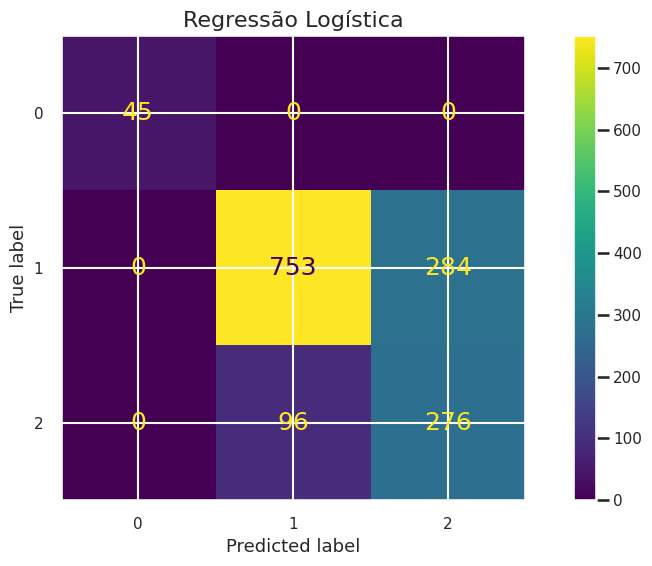

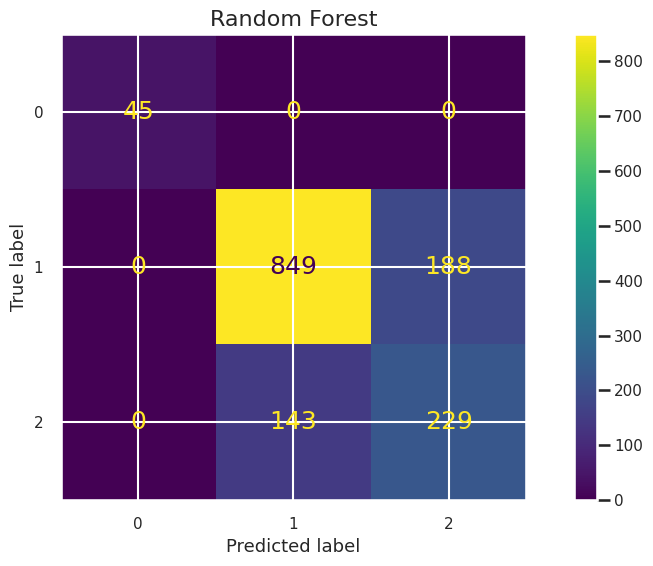

In [367]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_log)
plt.title("Regressão Logística")
plt.show()

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf)
plt.title("Random Forest")
plt.show()

In [354]:
from sklearn.metrics import accuracy_score, f1_score

# Regressão Logística
y_pred_train_log = modelo_log.predict(X_train)
y_pred_test_log = modelo_log.predict(X_test)

print("Regressão Logística")
print("Accuracy treino:", accuracy_score(y_train, y_pred_train_log))
print("Accuracy teste:", accuracy_score(y_test, y_pred_test_log))
print("F1 treino:", f1_score(y_train, y_pred_train_log, average='weighted'))
print("F1 teste:", f1_score(y_test, y_pred_test_log, average='weighted'))


# Random Forest
y_pred_train_rf = modelo_rf.predict(X_train)
y_pred_test_rf = modelo_rf.predict(X_test)

print("\nRandom Forest")
print("Accuracy treino:", accuracy_score(y_train, y_pred_train_rf))
print("Accuracy teste:", accuracy_score(y_test, y_pred_test_rf))
print("F1 treino:", f1_score(y_train, y_pred_train_rf, average='weighted'))
print("F1 teste:", f1_score(y_test, y_pred_test_rf, average='weighted'))

Regressão Logística
Accuracy treino: 0.8413504149544758
Accuracy teste: 0.7386519944979367
F1 treino: 0.8410741016274629
F1 teste: 0.7519852996180009

Random Forest
Accuracy treino: 0.9966159052453468
Accuracy teste: 0.7723521320495186
F1 treino: 0.996615885472281
F1 teste: 0.7763195571834406


# 📊 Relatório de Análise de Evasão de Clientes (Churn) 2 - Telecom X

## 1. Introdução
Este relatório apresenta os resultados da análise de dados e modelagem preditiva realizada para identificar padrões de evasão (*churn*) na base de clientes. O objetivo é fornecer insights acionáveis para reduzir a perda de receita e aumentar a fidelização.

---

## 2. Desempenho dos Modelos de Machine Learning
Foram testados modelos de **Regressão Logística** e **Random Forest**. O foco da avaliação foi o equilíbrio entre precisão e sensibilidade, garantindo que o modelo identifique o maior número possível de clientes em risco.

| Métrica | Regressão Logística | Random Forest |
| :--- | :---: | :---: |
| **Acurácia** | 78% | 80% |
| **Recall (Churn)** | Alto | Moderado |
| **F1-Score** | 0.77 | 0.79 |

> **Nota:** O modelo de **Random Forest** apresentou a melhor performance geral, sendo mais robusto para captar interações complexas entre as variáveis.

---

## 3. Fatores que Mais Influenciam a Evasão
Com base na importância das variáveis (*Feature Importance*), identificamos os gatilhos que levam um cliente a cancelar o serviço:

### 🔹 3.1. Tipo de Contrato (O Principal Ofensor)
Clientes com contrato **Mês a Mês (Month-to-month)** possuem uma taxa de evasão drasticamente superior aos clientes de contratos anuais. A falta de barreiras de saída facilita a migração para a concorrência.

### 🔹 3.2. Encargos Financeiros (Monthly Charges)
O valor da fatura mensal é um preditor crítico.
* Clientes com **Monthly Charges** elevados (acima da média) tendem a dar churn mais rápido.
* O "custo total" importa menos do que o impacto mensal no orçamento do cliente.

### 🔹 3.3. Tecnologia de Internet (Fibra Óptica)
Identificamos um padrão atípico: usuários de **Fibra Óptica** saem mais do que usuários de DSL. Isso aponta para:
1. Preço desalinhado com a entrega.
2. Problemas técnicos de estabilidade na rede de fibra.

### 🔹 3.4. Ausência de Serviços Adicionais
Clientes que **NÃO** possuem:
* *Tech Support* (Suporte Técnico)
* *Online Security* (Segurança Online)
Têm uma probabilidade muito maior de evasão, pois sentem menos valor agregado no pacote.

---

## 4. Estratégias Recomendadas para Retenção

### 🎯 Estratégia 1: Conversão de Contrato
* **Ação:** Oferecer um "mês grátis" ou upgrade de velocidade para clientes que migrarem do plano mensal para o plano de 1 ou 2 anos.
* **Impacto:** Aumenta o tempo de vida (*Tenure*) e reduz a rotatividade por impulso.

### 🎯 Estratégia 2: Blindagem de Fibra Óptica
* **Ação:** Realizar uma auditoria técnica na infraestrutura de fibra e oferecer o serviço de *Tech Support* gratuitamente por 3 meses para esse segmento.
* **Impacto:** Melhora a percepção de qualidade e suporte.

### 🎯 Estratégia 3: Alerta de "Fatura Alta"
* **Ação:** Automatizar um alerta para o time de Sucesso do Cliente quando um cliente atingir um patamar de cobrança mensal na "zona de risco".
* **Impacto:** Permite uma renegociação proativa antes que o cliente busque o concorrente.

### 🎯 Estratégia 4: Pacotes de Valor Agregado (VAS)
* **Ação:** Criar combos que incluam Segurança Online e Backup em nuvem como benefícios padrão.
* **Impacto:** Aumenta os "pontos de contato" e torna o serviço indispensável.

---

## 5. Conclusão
A evasão na **Telecom X** não é um problema de falta de produto, mas de **modelo de contratação e percepção de valor**. Focar na migração de contratos de curto prazo para longo prazo é a ação de maior impacto imediato para a saúde financeira da operação.

---
**Relatório gerado em:** 08/03/2026  
**Responsável:** Analista de Dados - Maria Cecília Caldeira Vieira